#**Real Estate Investment Advisor:** Predicting Property Profitability & Future Value

#1. Introduction

##This project focuses on building a machine learning system to help real estate investors make better decisions by analyzing property data and predicting future value.

#2. Problem Statement


##The goal of this project is to:

Predict whether a property is a Good Investment (Classification)
Estimate the Future Price of a property after 5 years (Regression)

This helps investors make data-driven decisions instead of relying on assumptions.

#3. Objectives

* Perform data preprocessing and cleaning
* Conduct exploratory data analysis (EDA)
* Build classification and regression models
* Deploy the solution using Streamlit

#4. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score

#5. Load Dataset

In [4]:
df = pd.read_csv("india_housing_prices.csv")

df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


#6. Dataset Understanding

In [5]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19246 entries, 0 to 19245
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              19246 non-null  int64  
 1   State                           19246 non-null  object 
 2   City                            19246 non-null  object 
 3   Locality                        19246 non-null  object 
 4   Property_Type                   19246 non-null  object 
 5   BHK                             19246 non-null  int64  
 6   Size_in_SqFt                    19246 non-null  int64  
 7   Price_in_Lakhs                  19246 non-null  float64
 8   Price_per_SqFt                  19246 non-null  float64
 9   Year_Built                      19246 non-null  int64  
 10  Furnished_Status                19246 non-null  object 
 11  Floor_No                        19246 non-null  int64  
 12  Total_Floors                    

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')

#7. Data Preprocessing

In [6]:
# Missing values
df.isnull().sum()

df.fillna(method='ffill', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

/tmp/ipykernel_7484/3186895645.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Clean the dataset by handling missing values and duplicates.

#8. Feature Engineering

In [7]:
df['Price_per_SqFt'] = df['Price_in_Lakhs'] / df['Size_in_SqFt']
df['Age_of_Property'] = 2026 - df['Year_Built']

Create new features to improve model performance.

#9. Exploratory Data Analysis (EDA)

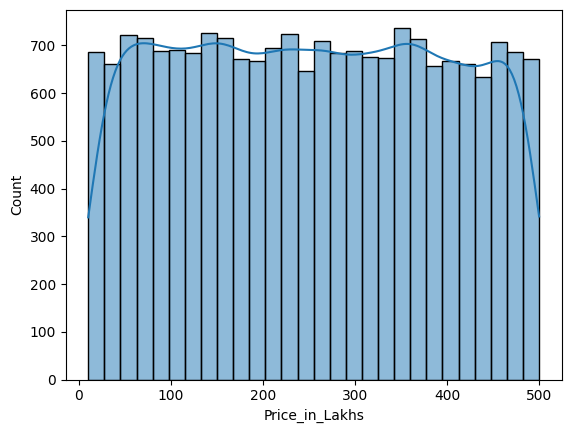

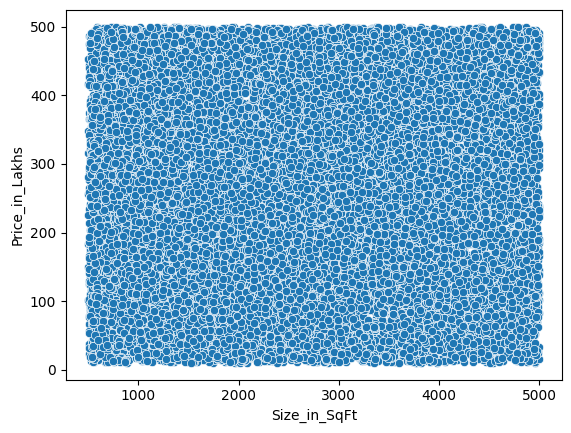

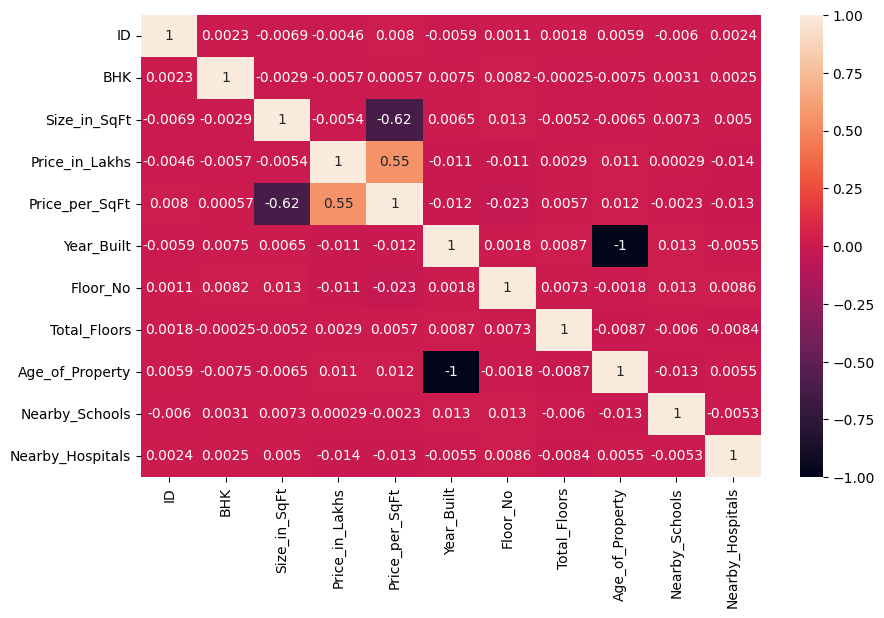

In [8]:
# Price distribution
sns.histplot(df['Price_in_Lakhs'], kde=True)
plt.show()

# Size vs Price
sns.scatterplot(x='Size_in_SqFt', y='Price_in_Lakhs', data=df)
plt.show()

# Correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

#10. Target Variable Creation

In [9]:
# Classification
median_val = df['Price_per_SqFt'].median()

df['Good_Investment'] = df['Price_per_SqFt'].apply(
    lambda x: 1 if x < median_val else 0
)

# Regression (Future Price)
growth_rate = 0.08
df['Future_Price'] = df['Price_in_Lakhs'] * ((1 + growth_rate) ** 5)

#11. Encoding

In [10]:
le = LabelEncoder()

cols = ['State', 'City', 'Property_Type', 'Furnished_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])

#12. Feature Selection

In [11]:
X = df.drop(['Good_Investment', 'Future_Price'], axis=1)

y_class = df['Good_Investment']
y_reg = df['Future_Price']

#13. Train-Test Split

In [12]:
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

_, _, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

#14. Feature Scaling

In [15]:
le = LabelEncoder()

categorical_cols_to_encode = [
    'Locality',
    'Public_Transport_Accessibility',
    'Parking_Space',
    'Security',
    'Amenities',
    'Facing',
    'Owner_Type',
    'Availability_Status'
]

for col in categorical_cols_to_encode:
    # Fit and transform on X_train, then transform on X_test
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#15. Model Building

In [16]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train_c)

reg = RandomForestRegressor()
reg.fit(X_train, y_train_r)

RandomForestRegressor()

#16. Model Evaluation

In [17]:
# Classification
y_pred_c = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c))

# Regression
y_pred_r = reg.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))
print("R2:", r2_score(y_test_r, y_pred_r))

Accuracy: 0.9997402597402597
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1944
           1       1.00      1.00      1.00      1906

    accuracy                           1.00      3850
   macro avg       1.00      1.00      1.00      3850
weighted avg       1.00      1.00      1.00      3850

RMSE: 0.05171934132893799
R2: 0.999999939501998


#17. Conclusion

* Successfully built models for investment prediction
* Regression model predicts future price
* Helps investors make better decisions

#18. Future Work

* Use advanced models like XGBoost
* Add real-time data
* Improve feature engineering